## Get the Required libraries

In [2]:
#basics Libraries 
import numpy as np
import pandas as pd

#Visualization libraries 
import matplotlib.pyplot as plt 
import pydot
import seaborn as sns

#Evaluation libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

#Deep learning libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers import Dense,Activation,Dropout
from keras.datasets import mnist
from keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [3]:
#pip install tensorflow

## Load the default dataset in the librarie

In [4]:
#Digit MNIST dataset
(x_train_digit, y_train_digit), (x_test_digit, y_test_digit) =mnist.load_data()

In [5]:
#check the input data set how it's looks, here i check the one image in the dataset(0 to 9)
x_train_digit[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [6]:
#check the output data set
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

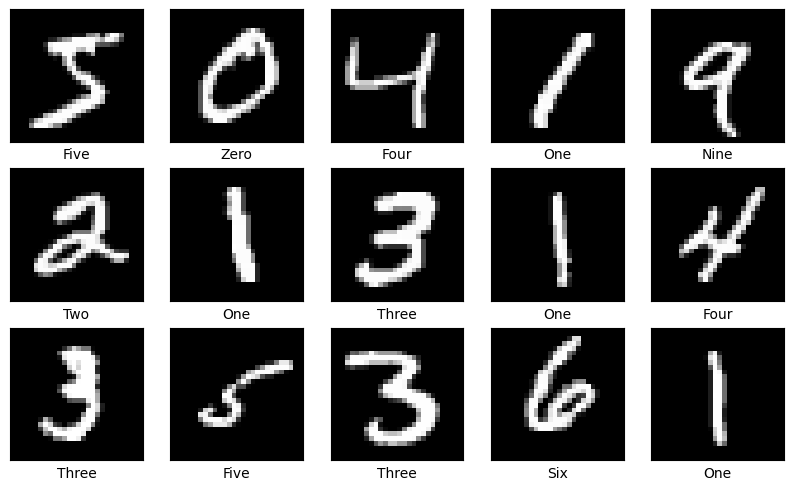

In [7]:
#Names of numbers in the dataset in order
col_names=["Zero","One","Two","Three","Four","Five","Six","Seven","Eight","Nine"]
#Visualizing the digits
plt.figure(figsize=(10,10))  #Image size 
for i in range(15):  #check the first 15 images in the dataset
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train_digit[i], cmap="gray")
    plt.xlabel(col_names[y_train_digit[i]])
plt.show()

# data preprocessing 

In [8]:
x_train_digit.shape

(60000, 28, 28)

In [10]:
x_test_digit.shape

(10000, 28, 28)

In [ ]:
#In this x_train_digit data was stored as a 3D. 60000 = count of the dataset 28 = rows, 28 = colums

In [ ]:
#In data preprocessing, we have to convert this 3D to 2D. ANN will working on 2D dataset
#Here we converts the rows and columns into only rows data in one line, the columns will comes next to the rows.so it will be come one line data.
#so we initiate the date 28 x 28 = 784, covert the into one data line 

In [12]:
x_train_digit=x_train_digit.reshape(60000,784)
x_test_digit=x_test_digit.reshape(10000,784)

In [13]:
x_train_digit.shape

(60000, 784)

In [14]:
y_train_digit.shape

(60000,)

In [15]:
y_train_digit

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [27]:
#If we take the Artificial Nural Network the data preprocessing should be input dataset be 2d so we have to conver the 3D to 2D and the output data should be One Hot Encoding

In [19]:
#Here we have 10 output so we have to classifi the 10 class, classes = the output which we have to predict
#Since it's classification, it have to predict the data between 0 to 9
#So we have to do the same ML preprocessing process. Encoding the output data(One hot encoding)

In [21]:
#Encoding the digit MNIST Labels
y_train_digit = to_categorical(y_train_digit, num_classes=10)

y_test_digit = to_categorical(y_test_digit, num_classes=10)

In [26]:
y_train_digit[2]
#here i search the num 2 in date in the train dataset, two was places in the 5th place so as per the encoding it was showing 1 other number are 0

array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])

# Creating the ANN brain

In [34]:
#This ANN model creation is a Sequential process 
#In below code, it's initiated the model one by one the date will goes into one layers to other layers 
#the below code is the set the procedure (creating the ruls) and it's only Feed Forward method

In [46]:
#Creating base neural netweok 
model = keras.Sequential([
    #Input layer
    layers.Dense(256, activation='relu', input_shape=(784,)), #In this line we give the input and next layer count 
    
    #it's below two lines add on if the model was not learned well then we use this to get the better result
    layers.Dropout(0.3),  #it will dropout the 0.3 value in the accuracy so the model think the accuracy was low so it will learn better
    layers.BatchNormalization(), #Same used in ML we have to conver the data into standard values 
    
    #Hidden layer 1
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    
    #Hidden layer 2
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    
    #Output layer
    layers.Dense(10,activation='sigmoid'),
])

In [93]:
#Data we 784 input data lines and 256 is no of neurons the first hidden layer and 256 is the playable parameter, hyperturning parameter we can change this num based on the results
#relu is the math validation, it validate the data output will comes to the next, Dense is the connections of the data and neuron
#The same on the hidden layers the first layer will takes  the data from the 256 neurons and passed into the next HL 1 in here it have 64 neurons, same for the HL 2 and outpur layer
#The output layers is the 10, beacuse we have 10 outputs in the data 0 to 9.

In [37]:
#Summary to view the Details of the ANN process
#Param_number = output_channel_number * (input_channel_number + 1)
#Example: 200,960 = 256 * (784 + 1), next layer 64 * (256 + 1)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
#Compiling the model 
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [49]:
#compile() prepares the model for training and used to configure the learning process
#It tells the model:
#loss = How to calculate error
#Optimizer = How to update weights (backpropagation method)
#Metrics = What metrics to track

## Fit method or Learning method 

In [50]:
result=model.fit(x_train_digit, y_train_digit, batch_size=100, epochs=10, validation_data=(x_test_digit, y_test_digit))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8364 - loss: 0.5432 - val_accuracy: 0.9492 - val_loss: 0.1712
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9305 - loss: 0.2430 - val_accuracy: 0.9652 - val_loss: 0.1167
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9441 - loss: 0.1965 - val_accuracy: 0.9690 - val_loss: 0.1046
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9536 - loss: 0.1665 - val_accuracy: 0.9704 - val_loss: 0.0931
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9576 - loss: 0.1504 - val_accuracy: 0.9730 - val_loss: 0.0897
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9607 - loss: 0.1380 - val_accuracy: 0.9693 - val_loss: 0.0981
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9629 - loss: 0.1273 - val_accuracy: 0.9748 - val_loss: 0.0859
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9652 - loss: 0.1220 - val_accuracy: 0.

In [44]:
#batch_size was 10, X_train have 60000 date so it seprate the data into 100 so we have 600 date sets
#One Epoch means it completed the Full FeedForward and Back propagation, it fit the data in 10 time do get the best result.
#validation_date it know how the model learned, while fiting the model it validate the data at the same time so we gave the validation_date here

In [45]:
#accuracy → performance on training data
#loss → error on training data
#val_accuracy → performance on new data
#val_loss → error on new data

In [51]:
# We got the good result after the add on on the ANN model (Droupout(0.3) and BatchNormalization() ) 

# Evaluation metrics

In [54]:
#Predicting the labels-DIGIT
y_predict = model.predict(x_test_digit)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [56]:
y_predict[0]
#the data were in unreadable 

array([0.2511387 , 0.35983375, 0.2577877 , 0.6996656 , 0.29921943,
       0.186052  , 0.0255622 , 0.99994755, 0.03519049, 0.86685884],
      dtype=float32)

In [57]:
y_predict=np.argmax(y_predict, axis=1)
# Here we get the index of maximum value in the encoded vector

In [70]:
#Predict output data
y_predict

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [62]:
y_test_digit[0]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [69]:
#Actual output data
y_test_digit_eval =np.argmax(y_test_digit, axis=1)

In [67]:
y_test_digit_eval

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [68]:
#we have to do reverse engineering so The all test data should suitable for process the confusion matrix

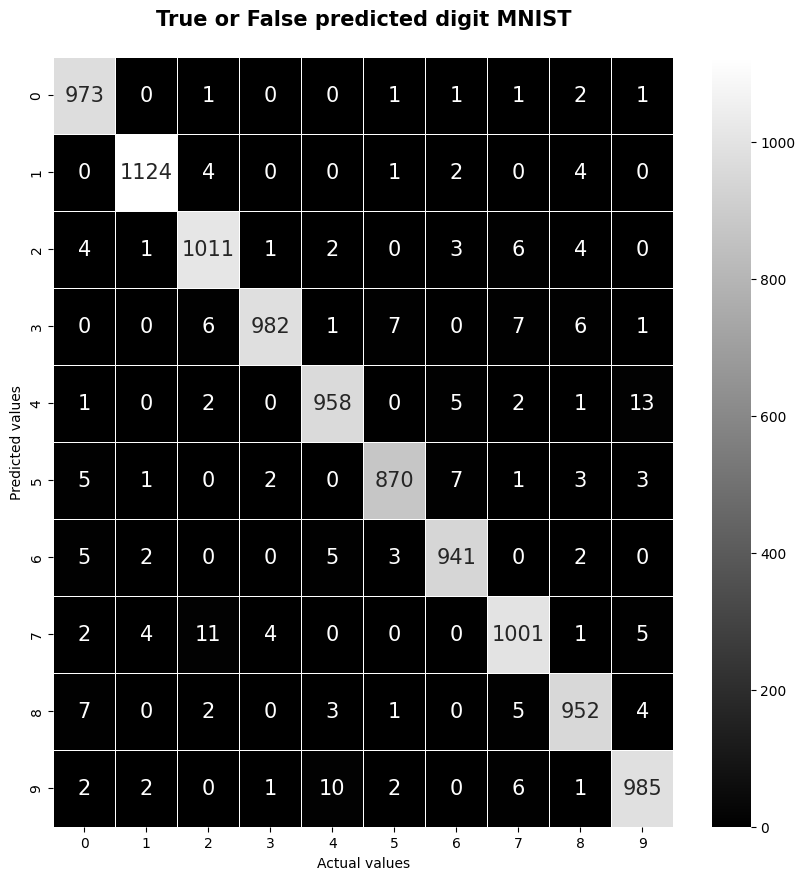

In [82]:
#Confusion matrix for Digit MNIST
#check the metric using heatmap
con_mat=confusion_matrix(y_test_digit_eval, y_predict)
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat, annot=True, annot_kws={'size': 15}, linewidths=0.5, fmt='d', cmap='gray')
plt.title("True or False predicted digit MNIST\n",fontweight='bold',fontsize=15)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.show()

In [83]:
#the result the balck colour it tells the not correcly classified and the White color color tells how correctly classified, number tells about the count of the data in overall data
#examples: Actual values 1 and predictive value 1 the score was 1124 means it predict the 1124 values correctly as a no 1

In [85]:
from sklearn.metrics import classification_report
print(classification_report(y_test_digit_eval, y_predict))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.99      0.97      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



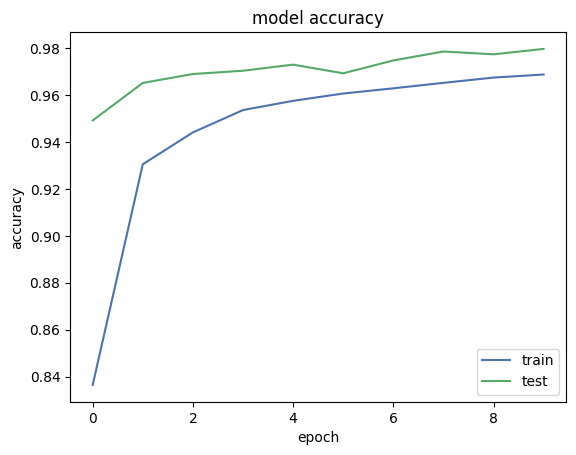

In [87]:
# summarize history for accuracy
plt.plot(result.history['accuracy'])
plt.plot(result.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='best')
plt.show()

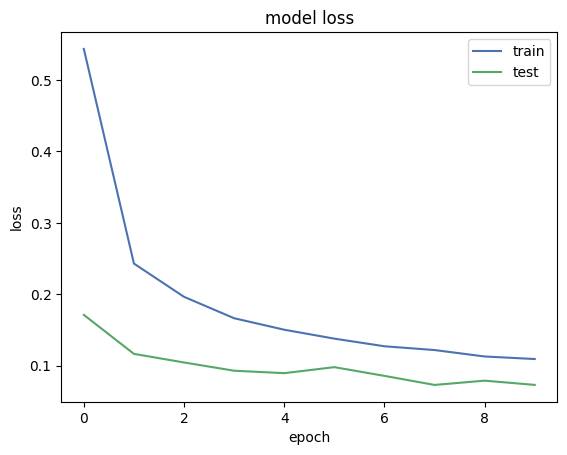

In [88]:
plt.plot(result.history['loss'])
plt.plot(result.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='best')
plt.show()

## User test

In [89]:
y_predict_single = model.predict(x_test_digit[[2]])
y_predicts_single = np.argmax(y_predict_single, axis=1) # Here we get the index of maximum value in the encoded vector
y_test_digit_eval=np.argmax(y_test_digit, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step


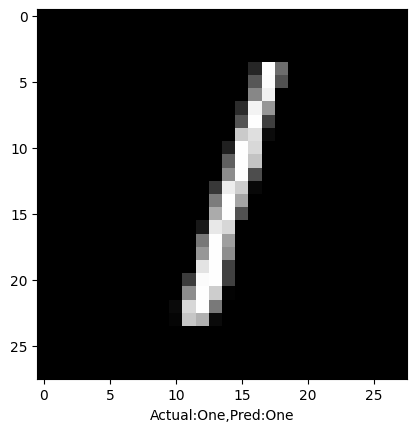

In [91]:
#Names of numbers in the dataset in order
col_names = ['Zero','One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

#Visualizing the digits
plt.imshow(x_test_digit[2].reshape(28,28), cmap='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[np.argmax(y_test_digit[2])],col_names[y_predicts_single[0]]))
plt.show()